using the same pipeline to build the ANN model in order to be able to compare the clinicalBERT transformer with the baseline RNN models that will be built

In [1]:
! git clone https://github.com/emilyrgarman/ml3finalproject_triage.git

fatal: destination path 'ml3finalproject_triage' already exists and is not an empty directory.


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

SEED = 42

In [3]:
train = pd.read_csv('/content/ml3finalproject_triage/train.csv')
test = pd.read_csv('/content/ml3finalproject_triage/test.csv')
complaints = pd.read_csv('/content/ml3finalproject_triage/chief_complaints.csv')
history = pd.read_csv('/content/ml3finalproject_triage/patient_history.csv')

In [4]:
train_df = train.merge(complaints[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')
train_df = train_df.merge(history, on='patient_id', how='left')
test_df  = test.merge(complaints[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')
test_df = test_df.merge(history, on='patient_id', how='left')

In [5]:
import re
SEVERITY_WORDS = ['mild', 'moderate', 'severe',
                  'critical', 'minor', 'major', 'actively',
                  'intermittent', 'in known patient']

def clean_complaint(x):
    x = re.split(r'[,，]', x)[0]
    return re.sub('|'.join(SEVERITY_WORDS), '', x, flags=re.IGNORECASE).strip()

train_df['cc_stripped'] = train_df['chief_complaint_raw'].apply(clean_complaint)
test_df['cc_stripped'] = test_df['chief_complaint_raw'].apply(clean_complaint)

In [6]:
NUMERIC_COLS = ['age', 'num_active_medications', 'num_comorbidities',
                'systolic_bp', 'diastolic_bp', 'heart_rate',
                'respiratory_rate', 'temperature_c', 'spo2',
                'gcs_total', 'pain_score', 'bmi',
                'num_prior_ed_visits_12m', 'num_prior_admissions_12m']
CATEG_COLS   = ['arrival_mode', 'sex', 'transport_origin',
                'pain_location', 'mental_status_triage']
DUMMY_COLS   = ['hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1',
                'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation',
                'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity',
                'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy',
                'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy',
                'hx_immunosuppressed', 'hx_pregnant', 'hx_substance_use_disorder',
                'hx_coronary_artery_disease', 'hx_stroke_prior',
                'hx_peripheral_vascular_disease']

ID_COLS      = ['patient_id', 'site_id', 'triage_nurse_id']
DISCARDED_COLS = ['arrival_hour', 'arrival_day',
                  'arrival_month', 'arrival_season', 'shift',
                  'age_group', 'disposition', 'shock_index',
                  'ed_los_hours', 'news2_score',
                  'mean_arterial_pressure', 'pulse_pressure',
                  'chief_complaint_system',
                  'language', 'insurance_type', 'weight_kg',
                  'height_cm']

TARGET_COL   = 'triage_acuity'
TEXT_COL     = 'chief_complaint_raw'
TABULAR_COLS = NUMERIC_COLS + CATEG_COLS + DUMMY_COLS

for col in CATEG_COLS:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_tab      = scaler.fit_transform(imputer.fit_transform(train_df[TABULAR_COLS]))
X_tab_test = scaler.transform(imputer.transform(test_df[TABULAR_COLS]))

# Shift labels 1–5 → 0–4 for CrossEntropyLoss
y = train_df[TARGET_COL].values - 1

# Train/val split
X_tr, X_val, y_tr, y_val, idx_tr, idx_val = train_test_split(
    X_tab, y, np.arange(len(y)),
    test_size=0.25, stratify=y, random_state=SEED
)

texts_all  = train_df[TEXT_COL].fillna('').values
texts_tr   = texts_all[idx_tr]
texts_val  = texts_all[idx_val]
texts_test = test_df[TEXT_COL].fillna('').values

print(f'\nTrain: {len(y_tr)} | Val: {len(y_val)} | Test: {len(test_df)}')


Train: 60000 | Val: 20000 | Test: 20000


In [7]:
import random
import re
import numpy as np

# ── Clinical abbreviations ─────────────────────────────────────────
ABBREV_MAP = {
    'with': 'w/',
    'without': 'w/o',
    'history of': 'hx of',
    'complaint of': 'c/o',
    'shortness of breath': 'SOB',
    'loss of consciousness': 'LOC',
    'atrial fibrillation': 'AF',
    'diabetic ketoacidosis': 'DKA',
    'urinary tract infection': 'UTI',
    'motor vehicle accident': 'MVA',
    'chest pain': 'CP',
    'blood pressure': 'BP',
    'heart rate': 'HR',
    'nausea and vomiting': 'N&V',
    'upper respiratory tract infection': 'URTI',
    'shortness of breath': 'SOB',
    'gastrointestinal': 'GI',
    'myocardial infarction': 'MI',
    'pulmonary embolism': 'PE',
    'deep vein thrombosis': 'DVT',
    'electrocardiogram': 'ECG',
    'fracture': 'frx',
    'laceration': 'lac',
    'abdominal': 'abd',
    'bilateral': 'bil',
}

# ── Typos ──────────────────────────────────────────────────────────
TYPO_MAP = {
    'fever': ['fevre', 'fver', 'fevr'],
    'pain': ['paon', 'pian', 'pan'],
    'vomiting': ['vomitting', 'vomitng', 'vomitin'],
    'breathing': ['breathng', 'brething', 'breathin'],
    'headache': ['headach', 'headche', 'hedache'],
    'abdominal': ['abdomnal', 'abdomial', 'abdomianl'],
    'dizziness': ['dizzness', 'diziness', 'dizzines'],
    'swelling': ['sweling', 'swlling', 'sweeling'],
    'bleeding': ['bleeing', 'bleding', 'bleedin'],
    'fracture': ['fractue', 'fractrure', 'fractyre'],
    'infection': ['infecton', 'infeccion', 'infectoin'],
    'severe': ['severre', 'seveer', 'sevre'],
    'chronic': ['chronc', 'chornic', 'chonic'],
    'acute': ['acuте', 'acte', 'acut'],
    'nausea': ['nasea', 'nauseau', 'nasuea'],
    'laceration': ['laceraion', 'lacerartion', 'laceraton'],
    'palpitations': ['palpitaions', 'palpitaitons', 'palpitatons'],
    'dyspnoea': ['dyspnoea', 'dyspnea', 'dispnoea'],
    'haemorrhage': ['haemmorhage', 'heamorrhage', 'haemorrhge'],
}

def abbreviate(text, p=0.5):
    for term, abbrev in ABBREV_MAP.items():
        if term in text.lower() and random.random() < p:
            text = re.sub(term, abbrev, text, flags=re.IGNORECASE)
    return text

def add_typos(text, p=0.2):
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in TYPO_MAP and random.random() < p:
            words[i] = random.choice(TYPO_MAP[word.lower()])
    return ' '.join(words)

def augment(text):
    text = abbreviate(text, p=0.5)
    text = add_typos(text, p=0.2)
    return text

# ── Apply to train only ────────────────────────────────────────────
random.seed(42)

aug_texts  = [augment(t) for t in texts_tr]
aug_labels = y_tr.copy()

texts_tr_aug = np.concatenate([texts_tr, aug_texts])
y_tr_aug     = np.concatenate([y_tr,     aug_labels])

print(f'Train size before aug: {len(texts_tr)}')
print(f'Train size after aug:  {len(texts_tr_aug)}')

# Sanity check
for orig, aug in zip(texts_tr[:5], aug_texts[:5]):
    print(f'  ORIG: {orig}')
    print(f'  AUG:  {aug}')
    print()

Train size before aug: 60000
Train size after aug:  120000
  ORIG: status epilepticus refractory with vomiting
  AUG:  status epilepticus refractory with vomitng

  ORIG: dehydration moderate in known patient
  AUG:  dehydration moderate in known patient

  ORIG: mild dysuria with fever
  AUG:  mild dysuria w/ fevre

  ORIG: minor skin rash
  AUG:  minor skin rash

  ORIG: palpitations with near-syncope, constant
  AUG:  palpitations with near-syncope, constant



using the same ANN model in order to make fair comparisons

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Model definition ───────────────────────────────────────────────
class TabularANN(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)  # raw logits

# ── DataLoaders ────────────────────────────────────────────────────
def make_loader(X, y=None, batch_size=256, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)

tr_loader  = make_loader(X_tr,  y_tr,  shuffle=True)
val_loader = make_loader(X_val, y_val)

# ── Training ───────────────────────────────────────────────────────
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS  = 30

ann       = TabularANN(input_dim=X_tr.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(ann.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss, best_state = float('inf'), None

for epoch in range(1, EPOCHS + 1):
    ann.train()
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(ann(Xb), yb)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # Validation
    ann.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            logits = ann(Xb.to(DEVICE))
            val_loss += criterion(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(val_loader)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = ann.state_dict()

    if epoch % 5 == 0:
        from sklearn.metrics import f1_score
        f1 = f1_score(trues, preds, average='macro')
        print(f'Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

ann.load_state_dict(best_state)
print('Training complete. Best val loss:', round(best_val_loss, 4))

# ── Get probabilities for fusion later ────────────────────────────
def get_probs(model, X):
    model.eval()
    loader = make_loader(X)
    probs  = []
    with torch.no_grad():
        for (Xb,) in loader:
            logits = model(Xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs)

ann_val_probs  = get_probs(ann, X_val)   # save for late fusion
ann_test_probs = get_probs(ann, X_tab_test)

Epoch   5 | Val Loss: 0.4431 | Val Macro-F1: 0.8316
Epoch  10 | Val Loss: 0.4165 | Val Macro-F1: 0.8392
Epoch  15 | Val Loss: 0.4060 | Val Macro-F1: 0.8434
Epoch  20 | Val Loss: 0.3989 | Val Macro-F1: 0.8446
Epoch  25 | Val Loss: 0.3965 | Val Macro-F1: 0.8461
Epoch  30 | Val Loss: 0.3964 | Val Macro-F1: 0.8462
Training complete. Best val loss: 0.3964


building the RNN baseline model using LSTM (since clinical notes can have multiple notes regarding patient condition, it may be useful to use a model that can account for long term dependencies)

In [20]:
# building the tokens from the clinical notes text

from collections import Counter

MAX_VOCAB = 20000
MAX_LEN   = 10

def tokenize(text):
    return text.lower().split()

# build vocab from training data
counter = Counter()
for text in texts_tr:
    counter.update(tokenize(text))

vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(MAX_VOCAB))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(t, 1) for t in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))
    return ids

X_text_tr  = np.array([encode(t) for t in texts_tr])
X_text_val= np.array([encode(t) for t in texts_val])
X_text_test= np.array([encode(t) for t in texts_test])

In [21]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    #def forward(self, x):
      #emb = self.embedding(x)
      #lengths = (x != 0).sum(dim=1).cpu()

      #packed = nn.utils.rnn.pack_padded_sequence(
       #   emb, lengths, batch_first=True, enforce_sorted=False
      #)
      #_, (h, _) = self.lstm(packed)

      #out = self.fc(self.dropout(h[-1]))
      #return out, h[-1]

    # we can fine tune this model later, but it gives very bad results because it essentially
    # predicts the majority class when max_len is set to 50
    def forward(self, x):
        emb = self.embedding(x)                # this is the batch size, sequence length, and embedding size
        _, (h, _) = self.lstm(emb)             # this is final hidden state
        out = self.fc(self.dropout(h[-1]))     # this is the batch size and the number of levels in target variable
        return out, h[-1]                      # this is returning the embeddings for fusion

In [22]:
def make_text_loader(X, y=None, batch_size=128, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.long)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)

tr_text_loader  = make_text_loader(X_text_tr,  y_tr, shuffle=True)
val_text_loader = make_text_loader(X_text_val, y_val)

In [23]:
rnn = RNNClassifier(vocab_size=len(vocab)).to(DEVICE)
optimizer = torch.optim.Adam(rnn.parameters(), lr=5e-4)
class_counts = np.bincount(y_tr)
weights = 1.0 / class_counts
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE)
)

from sklearn.metrics import f1_score
import numpy as np

train_losses, val_losses = [], []

for epoch in range(10):
    # train
    rnn.train()
    total_loss = 0

    for Xb, yb in tr_text_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits, _ = rnn(Xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(tr_text_loader)

    # validation
    rnn.eval()
    val_loss = 0
    preds, trues = [], []

    with torch.no_grad():
        for Xb, yb in val_text_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

            logits, _ = rnn(Xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()

            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())

    avg_val_loss = val_loss / len(val_text_loader)
    f1 = f1_score(trues, preds, average='macro')
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Val F1:     {f1:.4f}")
    print("-" * 40)

Epoch 1
Train Loss: 0.6381
Val Loss:   0.0392
Val F1:     0.9857
----------------------------------------
Epoch 2
Train Loss: 0.0326
Val Loss:   0.0134
Val F1:     0.9924
----------------------------------------
Epoch 3
Train Loss: 0.0118
Val Loss:   0.0065
Val F1:     0.9936
----------------------------------------
Epoch 4
Train Loss: 0.0071
Val Loss:   0.0051
Val F1:     0.9936
----------------------------------------
Epoch 5
Train Loss: 0.0050
Val Loss:   0.0047
Val F1:     0.9935
----------------------------------------
Epoch 6
Train Loss: 0.0053
Val Loss:   0.0050
Val F1:     0.9975
----------------------------------------
Epoch 7
Train Loss: 0.0100
Val Loss:   0.0679
Val F1:     0.9780
----------------------------------------
Epoch 8
Train Loss: 0.0164
Val Loss:   0.0051
Val F1:     0.9939
----------------------------------------
Epoch 9
Train Loss: 0.0050
Val Loss:   0.0046
Val F1:     0.9935
----------------------------------------
Epoch 10
Train Loss: 0.0047
Val Loss:   0.0048

when using the v6e1 gpu, training 10 epochs for this RNN took 45 seconds

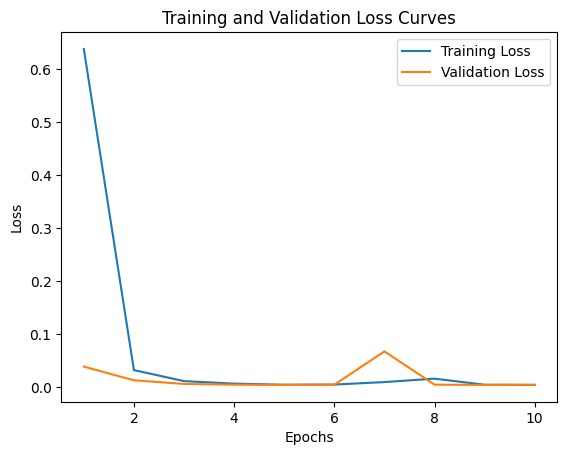

In [24]:
import matplotlib.pyplot as plt
def plot_losses(train_losses, val_losses):
  # plotting the loss curve
  epochs = range(1, len(train_losses) + 1)
  plt.plot(epochs, train_losses, label='Training Loss')
  plt.plot(epochs, val_losses, label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.title('Training and Validation Loss Curves')

  plt.show()

plot_losses(train_losses, val_losses)


In [25]:
def get_rnn_outputs(model, X):
    model.eval()
    loader = make_text_loader(X)
    probs, embs = [], []
    with torch.no_grad():
        for (Xb,) in loader:
            logits, h = model(Xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            embs.append(h.cpu().numpy())
    return np.vstack(probs), np.vstack(embs)

rnn_tr_probs,  rnn_tr_embs  = get_rnn_outputs(rnn, X_text_tr)
rnn_val_probs,  rnn_val_embs  = get_rnn_outputs(rnn, X_text_val)
rnn_test_probs, rnn_test_embs = get_rnn_outputs(rnn, X_text_test)

In [26]:
# probability averaging
late_val_probs = (ann_val_probs + rnn_val_probs) / 2
late_test_probs = (ann_test_probs + rnn_test_probs) / 2

late_val_preds = late_val_probs.argmax(axis=1)

In [27]:
# building the early fusion models
early_tr_X   = np.concatenate([rnn_tr_embs,  X_tr],       axis=1)
early_val_X  = np.concatenate([rnn_val_embs,  X_val],      axis=1)
early_test_X = np.concatenate([rnn_test_embs, X_tab_test], axis=1)  # fix: X_tab_test not X_test_

INPUT_DIM = early_tr_X.shape[1]

#  using the same early fusion model definition
class EarlyFusionHead(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[256, 128], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

fusion_head = EarlyFusionHead(input_dim=INPUT_DIM).to(DEVICE)

ef_tr_loader  = make_loader(early_tr_X,  y_tr,  shuffle=True)
ef_val_loader = make_loader(early_val_X, y_val)

# defining the training loop
EPOCHS_EF = 20
optimizer_ef  = torch.optim.AdamW(fusion_head.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_ef  = nn.CrossEntropyLoss()
scheduler_ef  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ef, T_max=EPOCHS_EF)

best_val_loss_ef, best_state_ef = float('inf'), None

for epoch in range(1, EPOCHS_EF + 1):
    fusion_head.train()
    for Xb, yb in ef_tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_ef.zero_grad()
        loss = criterion_ef(fusion_head(Xb), yb)
        loss.backward()
        optimizer_ef.step()
    scheduler_ef.step()

    # Validation
    fusion_head.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in ef_val_loader:
            logits = fusion_head(Xb.to(DEVICE))
            val_loss += criterion_ef(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(ef_val_loader)
    if val_loss < best_val_loss_ef:
        best_val_loss_ef = val_loss
        best_state_ef    = fusion_head.state_dict()

    if epoch % 5 == 0:
        f1 = f1_score(trues, preds, average='macro')
        print(f'Epoch {epoch:3d} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

fusion_head.load_state_dict(best_state_ef)
print('Best val loss:', round(best_val_loss_ef, 4))

# getting early fusion predictions
ef_val_preds  = fusion_head(torch.tensor(early_val_X,  dtype=torch.float32).to(DEVICE))
ef_test_preds = fusion_head(torch.tensor(early_test_X, dtype=torch.float32).to(DEVICE))

ef_val_preds  = ef_val_preds.argmax(1).cpu().numpy()
ef_test_preds = ef_test_preds.argmax(1).cpu().numpy()

Epoch   5 | Val Loss: 0.0007 | Val Macro-F1: 0.9992
Epoch  10 | Val Loss: 0.0011 | Val Macro-F1: 0.9991
Epoch  15 | Val Loss: 0.0007 | Val Macro-F1: 0.9994
Epoch  20 | Val Loss: 0.0007 | Val Macro-F1: 0.9994
Best val loss: 0.0005


In [28]:
for name, p in [('ANN only',      ann_val_probs.argmax(1)),
                ('RNN only',     rnn_val_probs.argmax(1)),
                ('Late Fusion',   late_val_preds),
                ('Early Fusion',  ef_val_preds)]:
    f1 = f1_score(y_val.squeeze(), p, average='macro')
    print(f'{name:<20} Macro-F1: {f1:.4f}')

ANN only             Macro-F1: 0.8462
RNN only             Macro-F1: 0.9938
Late Fusion          Macro-F1: 0.9997
Early Fusion         Macro-F1: 0.9994


In [29]:
import numpy as np

# Cost matrix: cost[true][pred] — penalizes by distance between acuity levels
cost_matrix = np.array([[0, 1, 2, 3, 4],
                         [1, 0, 1, 2, 3],
                         [2, 1, 0, 1, 2],
                         [3, 2, 1, 0, 1],
                         [4, 3, 2, 1, 0]])

def cost_sensitive_score(y_true, y_pred, cost_matrix):
    total_cost = sum(cost_matrix[t][p] for t, p in zip(y_true, y_pred))
    # normalize by worst possible cost
    worst_cost = sum(cost_matrix[t].max() for t in y_true)
    return 1 - (total_cost / worst_cost)  # higher is better

score = cost_sensitive_score(y_val.squeeze(), late_val_preds, cost_matrix)
print(f'Cost-sensitive score: {score:.4f}')

Cost-sensitive score: 1.0000


something is also wrong here

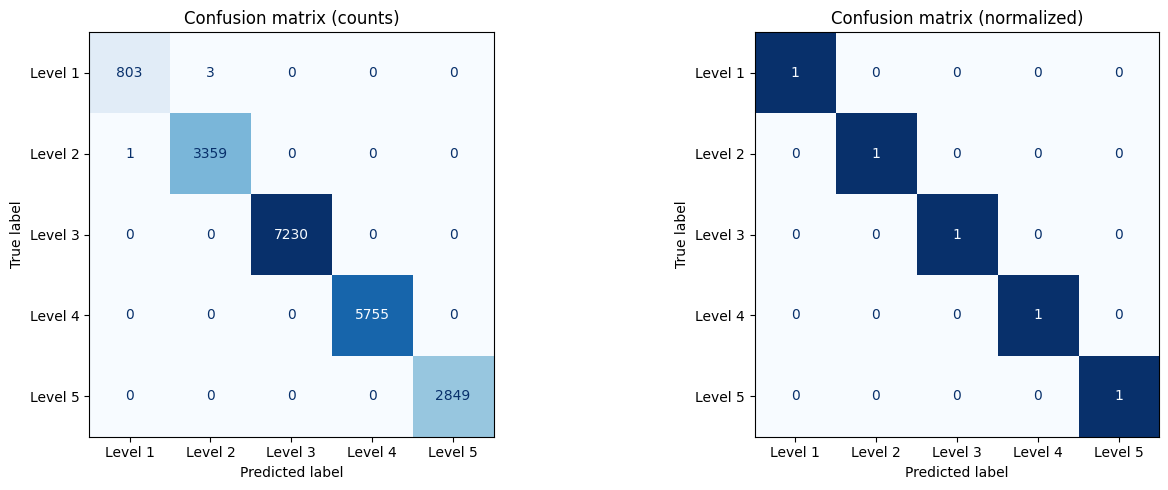

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
# visualizing confusion matrix

CLASS_NAMES = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

cm = confusion_matrix(y_val, ef_val_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (counts)')

# Normalized (easier to compare across class sizes)
disp_norm = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (normalized)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# its perfectly predicting, it might be the same issue with words such as
# mild, severe, etc. predicting for

i think we need to incorporate real life data, when the max len is really high, the RNN does worse at predicting. but as soon as i lower the max len to 10, it makes perfect predictions